# NDN Anomaly Detection — Global Isolation Forest Model

This notebook trains a **single global Isolation Forest** on combined normal traffic data from all three NDN topologies (tree, dumbbell, dfn),
then tests it on each topology's IFA (Interest Flooding Attack) dataset separately.
The focus is **per-node analysis** to understand how well the model distinguishes attacking nodes (c1) from benign nodes.

In [1]:
%matplotlib inline
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch, Rectangle
from scipy.stats import ks_2samp
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 150, "font.size": 9})

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "research_analysis" else Path.cwd()
LOGS_DIR     = PROJECT_ROOT / "Datacard" / "Logs"
FIG_DIR      = PROJECT_ROOT / "research_analysis" / "figures" / "global"
RES_DIR      = PROJECT_ROOT / "research_analysis" / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

# ── Feature names ──────────────────────────────────────────────────────────────
FEATURES = [
    "pit_size", "pit_growth_rate", "cs_size", "cache_hit_ratio",
    "satisfaction_ratio", "unsatisfied_ratio",
    "in_interests_rate", "out_interests_rate", "in_data_rate", "nack_rate"
]
FEAT_LABELS = [
    "PIT Size", "PIT Growth Rate", "CS Size", "Cache Hit Ratio",
    "Satisfaction Ratio", "Unsatisfied Ratio",
    "In-Interests Rate", "Out-Interests Rate", "In-Data Rate", "NACK Rate"
]

# ── Node colours ───────────────────────────────────────────────────────────────
NODE_COLORS = {
    "consumer":   "#4c72b0",
    "router":     "#dd8452",
    "producer":   "#55a868",
    "bottleneck": "#8172b2",
}

ATTACKER = "c1"

# ── Topology definitions ───────────────────────────────────────────────────────
TOPOLOGIES = {
    "tree": {
        "normal_dirs": [LOGS_DIR / "tree_normal_1", LOGS_DIR / "tree_normal_2"],
        "attack_dir":  LOGS_DIR / "tree_ifa",
        "nodes":       ["c1", "c2", "c3", "c4", "c5", "c6",
                        "p1", "p2", "r1", "r2", "r3", "r4"],
    },
    "dumbbell": {
        "normal_dirs": [LOGS_DIR / "dumbbell_normal"],
        "attack_dir":  LOGS_DIR / "dumbbell_ifa",
        "nodes":       ["c1", "c2", "c3",
                        "p1", "p2", "r1", "r2", "r3", "r4", "bottleneck"],
    },
    "dfn": {
        "normal_dirs": [LOGS_DIR / "dfn_normal"],
        "attack_dir":  LOGS_DIR / "dfn_ifa",
        "nodes":       ["c1", "c2", "c3", "c4", "c5", "c6",
                        "p1", "p2", "r1", "r2", "r3", "r4"],
    },
}

# ── Node type helpers ──────────────────────────────────────────────────────────
def node_type(node):
    if node.startswith("c"):          return "consumer"
    if node.startswith("p"):          return "producer"
    if node == "bottleneck":          return "bottleneck"
    return "router"

def node_order(node):
    """Sort key: consumers first, then producers, then routers, bottleneck last."""
    order = {"consumer": 0, "producer": 1, "router": 2, "bottleneck": 3}
    t = node_type(node)
    num = int("".join(filter(str.isdigit, node)) or 0)
    return (order[t], num)

def sorted_nodes(nodes):
    return sorted(nodes, key=node_order)

print("Paths and constants ready.")
print(f"  PROJECT_ROOT : {PROJECT_ROOT}")
print(f"  LOGS_DIR     : {LOGS_DIR}")
print(f"  FIG_DIR      : {FIG_DIR}")
print(f"  RES_DIR      : {RES_DIR}")

Paths and constants ready.
  PROJECT_ROOT : /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN
  LOGS_DIR     : /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/Datacard/Logs
  FIG_DIR      : /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global
  RES_DIR      : /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/results


In [3]:
# ── Feature engineering helpers ────────────────────────────────────────────────

def compute_features(base_path):
    """Load all *.jsonl files under base_path recursively,
    sort by node+timestamp, compute per-interval delta features.
    Returns a DataFrame with FEATURES columns plus 'node'.
    """
    records = []
    for jsonl_file in sorted(Path(base_path).rglob("*.jsonl")):
        with open(jsonl_file) as fh:
            for line in fh:
                line = line.strip()
                if line:
                    records.append(json.loads(line))

    if not records:
        return pd.DataFrame(columns=["node"] + FEATURES)

    df = pd.DataFrame(records)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["node", "timestamp"]).reset_index(drop=True)

    rows = []
    for node, grp in df.groupby("node", sort=False):
        grp = grp.reset_index(drop=True)
        if len(grp) < 2:
            continue

        ts   = grp["timestamp"]
        dt_s = ts.diff().dt.total_seconds().fillna(0)
        dt_s = dt_s.clip(lower=1e-6)

        def delta(col):
            return grp[col].diff().fillna(0)

        d_pit   = delta("nPitEntries")
        d_hits  = delta("nHits").clip(lower=0)
        d_miss  = delta("nMisses").clip(lower=0)
        d_sat   = delta("nSatisfiedInterests").clip(lower=0)
        d_unsat = delta("nUnsatisfiedInterests").clip(lower=0)
        d_inI   = delta("nInInterests").clip(lower=0)
        d_outI  = delta("nOutInterests").clip(lower=0)
        d_inD   = delta("nInData").clip(lower=0)
        d_nack  = (delta("nInNacks") + delta("nOutNacks")).clip(lower=0)

        hm_sum = d_hits + d_miss
        su_sum = d_sat + d_unsat

        feat_df = pd.DataFrame({
            "node":              node,
            "pit_size":          grp["nPitEntries"],
            "pit_growth_rate":   d_pit / dt_s,
            "cs_size":           grp["nCsEntries"],
            "cache_hit_ratio":   np.where(hm_sum > 0, d_hits / hm_sum, 0.0),
            "satisfaction_ratio":np.where(su_sum > 0, d_sat  / su_sum, 0.0),
            "unsatisfied_ratio": np.where(su_sum > 0, d_unsat/ su_sum, 0.0),
            "in_interests_rate": d_inI  / dt_s,
            "out_interests_rate":d_outI / dt_s,
            "in_data_rate":      d_inD  / dt_s,
            "nack_rate":         d_nack / dt_s,
        })
        # drop the first row (no delta)
        rows.append(feat_df.iloc[1:].reset_index(drop=True))

    if not rows:
        return pd.DataFrame(columns=["node"] + FEATURES)

    return pd.concat(rows, ignore_index=True)


# Rate columns that get clipped
RATE_COLS = ["pit_growth_rate", "in_interests_rate", "out_interests_rate",
             "in_data_rate", "nack_rate"]

def apply_clip(df, clip_bounds):
    """Clip rate columns using pre-computed P1/P99 bounds.
    Skips columns where hi <= lo (zero-variance / collapsed bounds).
    Returns a copy.
    """
    df = df.copy()
    for col, (lo, hi) in clip_bounds.items():
        if col in df.columns and hi > lo:
            df[col] = df[col].clip(lower=lo, upper=hi)
    return df


def make_normalizer(threshold, score_min, score_max):
    """Returns a vectorised numpy function that maps raw IF scores to [0, 100].
    score >= threshold → [30, 100]
    score <  threshold → [0,  30)
    """
    def _norm(scores):
        scores = np.asarray(scores, dtype=float)
        out = np.empty_like(scores)
        high = scores >= threshold
        denom_hi = score_max - threshold if score_max != threshold else 1.0
        denom_lo = threshold - score_min if threshold != score_min else 1.0
        out[high]  = 30.0 + (scores[high]  - threshold) / denom_hi * 70.0
        out[~high] = 30.0 * (scores[~high] - score_min) / denom_lo
        return np.clip(out, 0.0, 100.0)
    return _norm

print("Feature engineering helpers defined.")

Feature engineering helpers defined.


## 1. Training the Global Model

In [4]:
# ── Load all normal data ───────────────────────────────────────────────────────
normal_parts = []
for topo, info in TOPOLOGIES.items():
    for ndir in info["normal_dirs"]:
        df_part = compute_features(ndir)
        df_part["topology"] = topo
        df_part["source_dir"] = ndir.name
        normal_parts.append(df_part)
        print(f"  Loaded {len(df_part):>6d} rows from {ndir.name}")

df_normal_all = pd.concat(normal_parts, ignore_index=True)
print(f"\nTotal normal samples: {len(df_normal_all):,}")
print(df_normal_all[["topology", "node"]].value_counts().sort_index().to_string())

# ── Compute clip bounds (P1 / P99) on combined normal data ────────────────────
clip_bounds = {}
for col in RATE_COLS:
    lo = df_normal_all[col].quantile(0.01)
    hi = df_normal_all[col].quantile(0.99)
    clip_bounds[col] = (lo, hi)
    status = "SKIP (collapsed)" if hi <= lo else f"[{lo:.4f}, {hi:.4f}]"
    print(f"  clip {col}: {status}")

# ── Apply clip to normal data ─────────────────────────────────────────────────
df_normal_clipped = apply_clip(df_normal_all, clip_bounds)

# ── Train global Isolation Forest pipeline ────────────────────────────────────
X_train = df_normal_clipped[FEATURES].values

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("if",     IsolationForest(n_estimators=200, contamination=0.01, random_state=42)),
])
pipe.fit(X_train)

# ── Compute threshold / score range from training scores ──────────────────────
train_scores = pipe.decision_function(X_train)
THRESHOLD  = 0.0          # decision boundary: positive = normal
SCORE_MIN  = float(train_scores.min())
SCORE_MAX  = float(train_scores.max())

normalizer = make_normalizer(THRESHOLD, SCORE_MIN, SCORE_MAX)
train_norm  = normalizer(train_scores)

fpr_30 = (train_norm < 30).mean() * 100
fpr_50 = (train_norm < 50).mean() * 100

print(f"\n── Global Model Training Summary ──")
print(f"  Training samples : {len(X_train):,}")
print(f"  Score range      : [{SCORE_MIN:.4f}, {SCORE_MAX:.4f}]")
print(f"  Threshold (θ)    : {THRESHOLD}")
print(f"  FPR @ 30 %       : {fpr_30:.2f}%")
print(f"  FPR @ 50 %       : {fpr_50:.2f}%")

  Loaded  12912 rows from tree_normal_1
  Loaded   6033 rows from tree_normal_2


  Loaded  18981 rows from dumbbell_normal


  Loaded  16963 rows from dfn_normal

Total normal samples: 54,889
topology  node      
dfn       c1            1414
          c2            1414
          c3            1414
          c4            1414
          c5            1414
          c6            1414
          p1            1414
          p2            1413
          r1            1413
          r2            1413
          r3            1413
          r4            1413
dumbbell  bottleneck    1899
          c1            1898
          c2            1898
          c3            1898
          p1            1898
          p2            1898
          r1            1898
          r2            1898
          r3            1898
          r4            1898
tree      c1            1579
          c2            1579
          c3            1579
          c4            1579
          c5            1579
          c6            1579
          p1            1579
          p2            1579
          r1            1579
          r2 


── Global Model Training Summary ──
  Training samples : 54,889
  Score range      : [-0.1284, 0.2714]
  Threshold (θ)    : 0.0
  FPR @ 30 %       : 1.00%
  FPR @ 50 %       : 3.88%


In [5]:
# ── Score IFA datasets ────────────────────────────────────────────────────────
ifa_parts = []

for topo, info in TOPOLOGIES.items():
    df_ifa = compute_features(info["attack_dir"])
    df_ifa["topology"] = topo
    df_ifa = apply_clip(df_ifa, clip_bounds)

    X_ifa = df_ifa[FEATURES].values
    raw   = pipe.decision_function(X_ifa)
    norm  = normalizer(raw)

    df_ifa["raw_score"]  = raw
    df_ifa["norm_score"] = norm
    df_ifa["anom_30"]    = norm < 30
    df_ifa["anom_50"]    = norm < 50

    ifa_parts.append(df_ifa)
    det30 = df_ifa[df_ifa["node"] == ATTACKER]["anom_30"].mean() * 100
    det50 = df_ifa[df_ifa["node"] == ATTACKER]["anom_50"].mean() * 100
    print(f"  {topo:12s}: {len(df_ifa):>6d} rows  "
          f" c1 det@30%={det30:.1f}%  c1 det@50%={det50:.1f}%")

df_ifa_all = pd.concat(ifa_parts, ignore_index=True)

# Save
out_csv = RES_DIR / "global_ifa_scored.csv"
df_ifa_all.to_csv(out_csv, index=False)
print(f"\nScoring complete. Saved {len(df_ifa_all):,} rows → {out_csv}")

  tree        :   3520 rows   c1 det@30%=89.5%  c1 det@50%=91.2%
  dumbbell    :   5370 rows   c1 det@30%=98.7%  c1 det@50%=98.7%


  dfn         :   7206 rows   c1 det@30%=96.7%  c1 det@50%=96.8%



Scoring complete. Saved 16,096 rows → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/results/global_ifa_scored.csv


## 2. Score Distributions

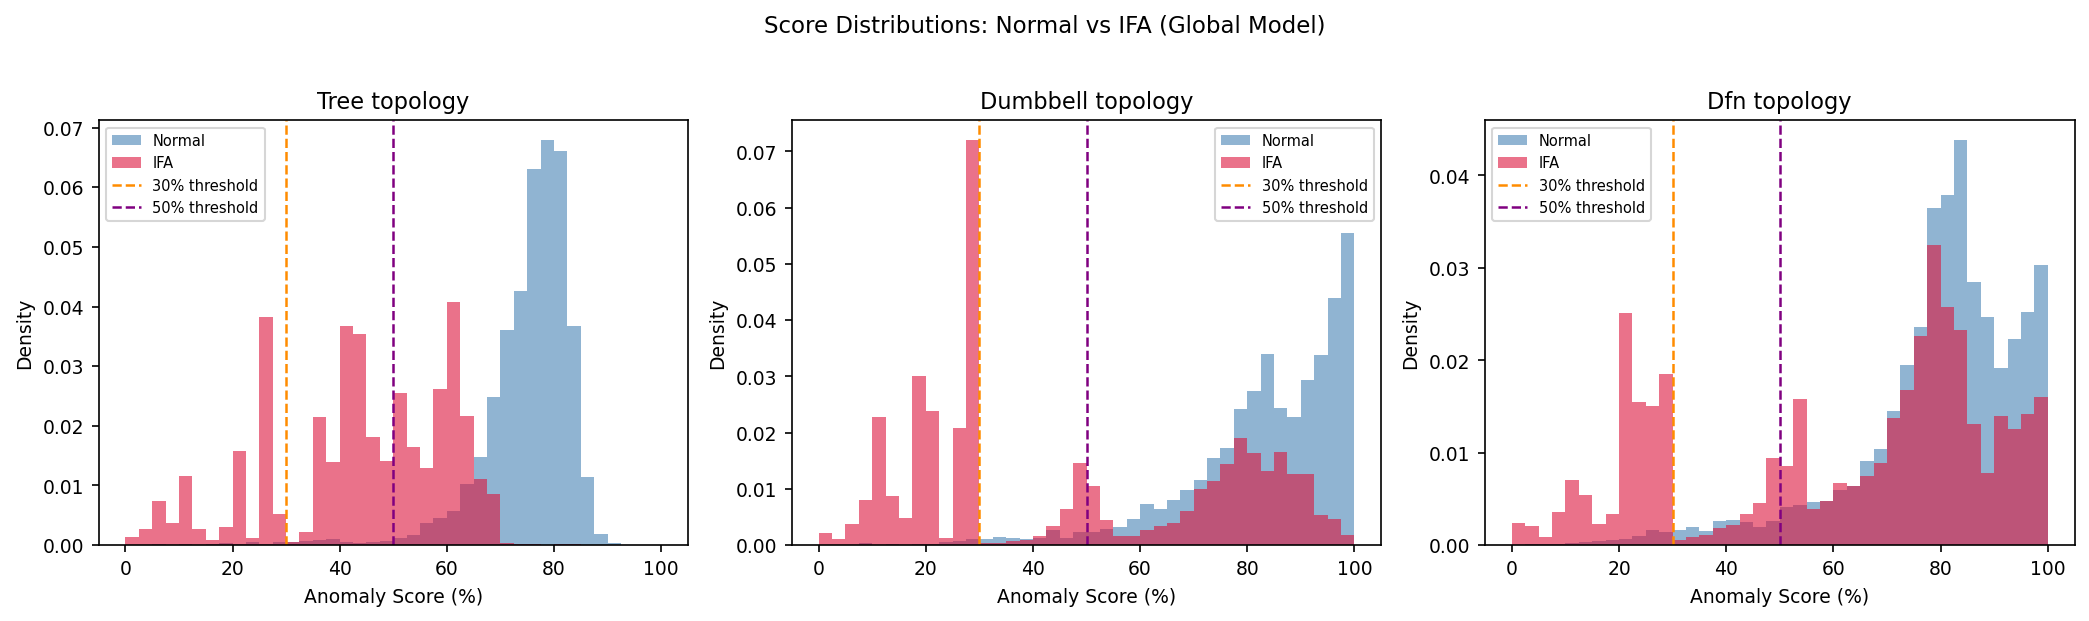

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_score_dist.png


In [6]:
# ── Score distribution: normal vs IFA per topology ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, (topo, info) in zip(axes, TOPOLOGIES.items()):
    # Normal scores (already computed on training data; filter by topology)
    mask_norm = df_normal_clipped["topology"] == topo
    X_norm_t  = df_normal_clipped.loc[mask_norm, FEATURES].values
    norm_sc   = normalizer(pipe.decision_function(X_norm_t))

    # IFA scores for this topology
    ifa_sc = df_ifa_all.loc[df_ifa_all["topology"] == topo, "norm_score"].values

    bins = np.linspace(0, 100, 41)
    ax.hist(norm_sc, bins=bins, alpha=0.6, color="steelblue", label="Normal",  density=True)
    ax.hist(ifa_sc,  bins=bins, alpha=0.6, color="crimson",   label="IFA",     density=True)

    ax.axvline(30, color="darkorange", linestyle="--", linewidth=1.2, label="30% threshold")
    ax.axvline(50, color="purple",     linestyle="--", linewidth=1.2, label="50% threshold")

    ax.set_xlabel("Anomaly Score (%)")
    ax.set_ylabel("Density")
    ax.set_title(f"{topo.capitalize()} topology")
    ax.legend(fontsize=7)

fig.suptitle("Score Distributions: Normal vs IFA (Global Model)", fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_score_dist.png", bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'fig_score_dist.png'}")

## 3. Per-Node Detection Rates

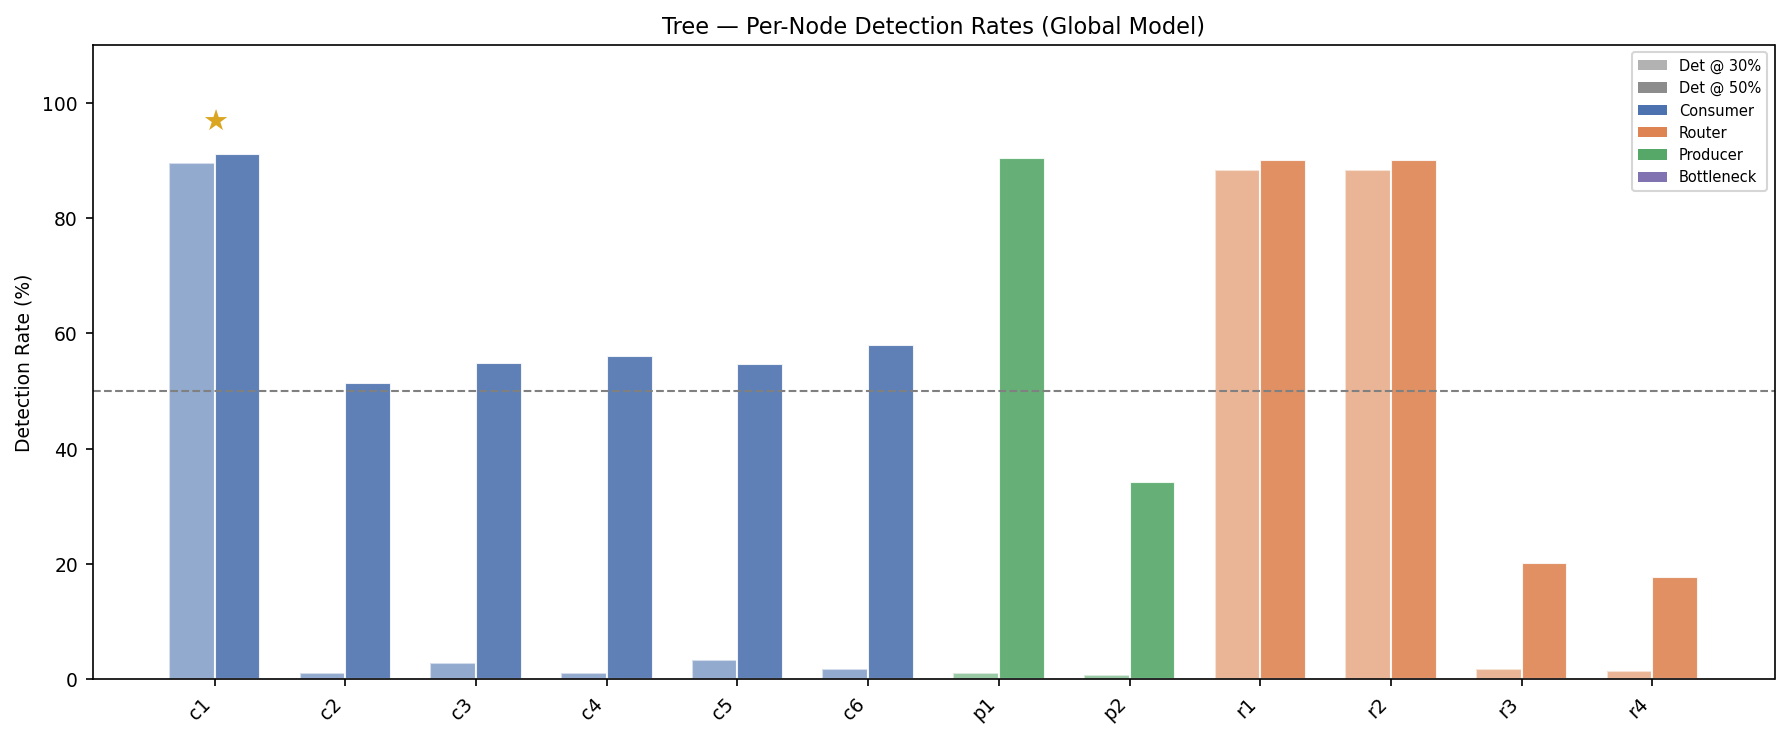

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_pernode_detection_tree.png


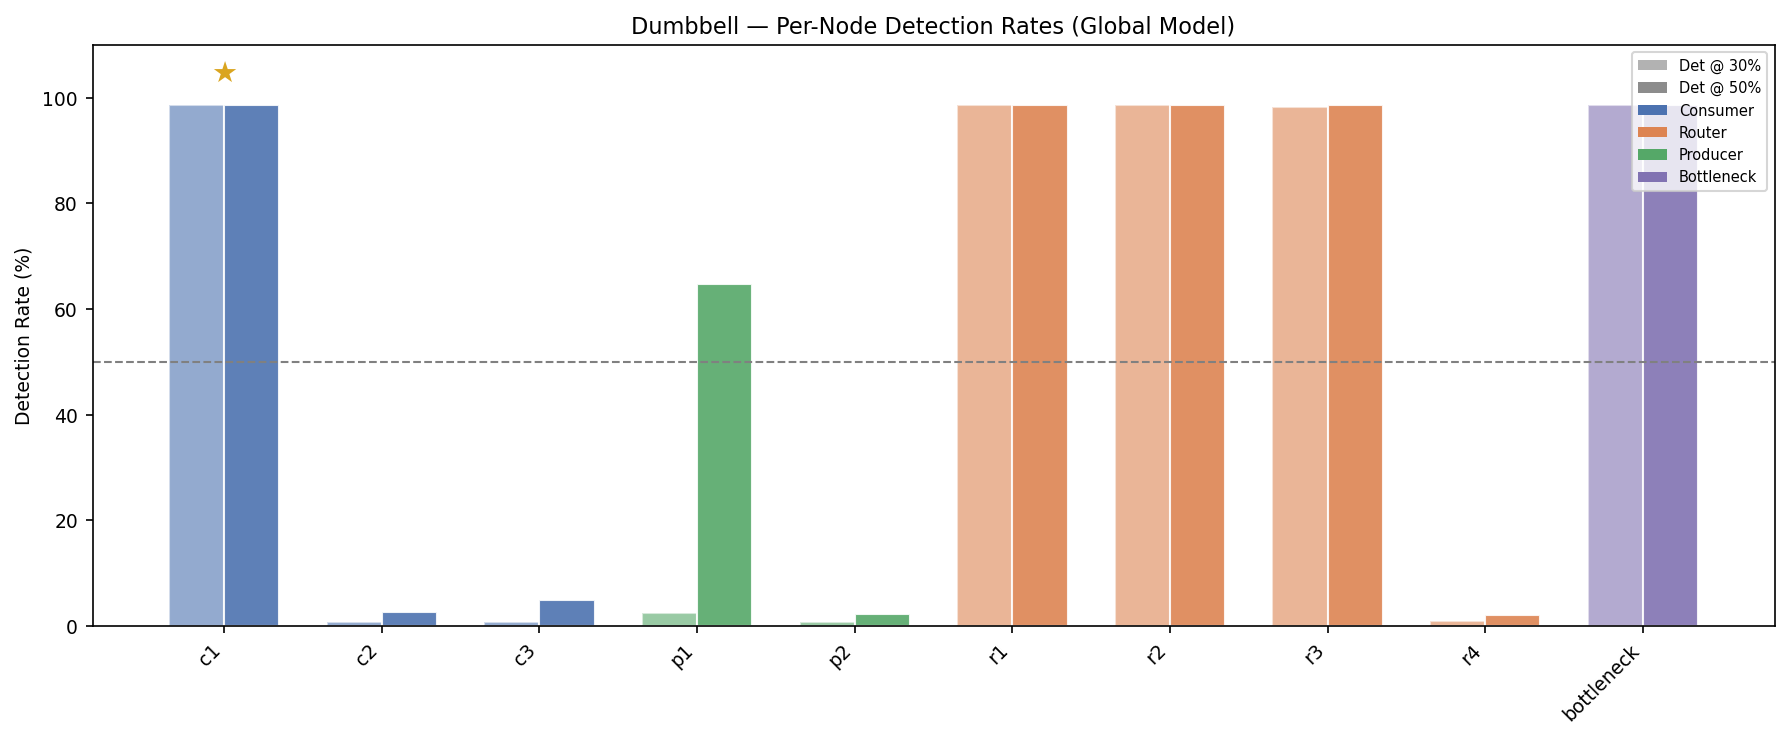

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_pernode_detection_dumbbell.png


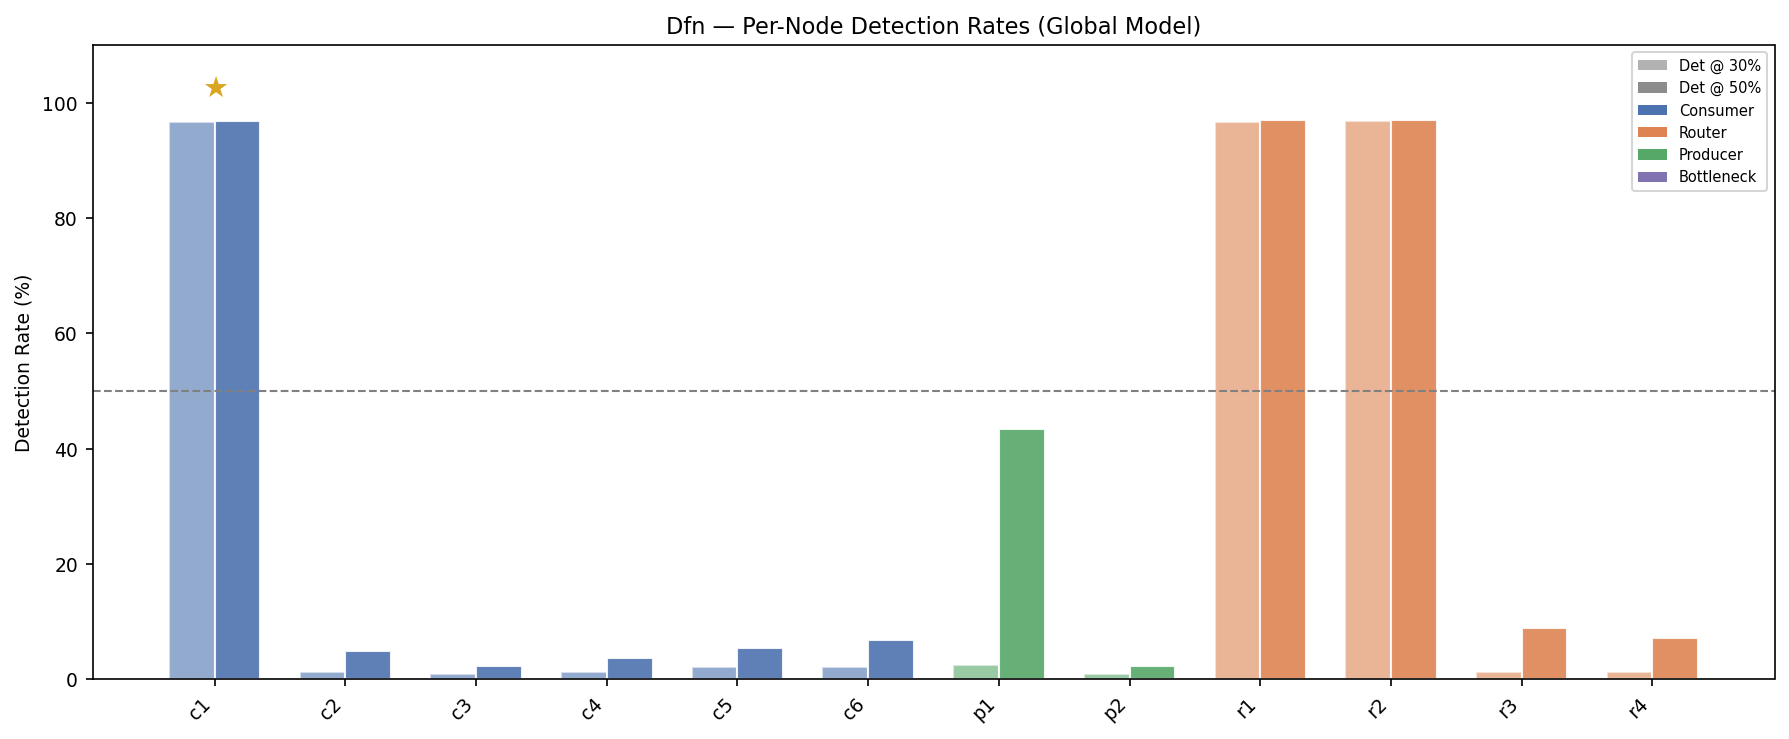

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_pernode_detection_dfn.png


In [7]:
def plot_pernode_detection(topo, df_ifa_topo):
    nodes = sorted_nodes(df_ifa_topo["node"].unique().tolist())
    n     = len(nodes)
    x     = np.arange(n)
    width = 0.35

    det30 = [df_ifa_topo[df_ifa_topo["node"] == nd]["anom_30"].mean() * 100 for nd in nodes]
    det50 = [df_ifa_topo[df_ifa_topo["node"] == nd]["anom_50"].mean() * 100 for nd in nodes]

    colors = [NODE_COLORS[node_type(nd)] for nd in nodes]

    fig, ax = plt.subplots(figsize=(12, 5))

    bars30 = ax.bar(x - width/2, det30, width, label="Det @ 30%",
                    color=[c for c in colors], alpha=0.6, edgecolor="white")
    bars50 = ax.bar(x + width/2, det50, width, label="Det @ 50%",
                    color=[c for c in colors], alpha=0.9, edgecolor="white")

    # Gold star above c1
    if ATTACKER in nodes:
        idx = nodes.index(ATTACKER)
        ymax = max(det30[idx], det50[idx])
        ax.text(idx, ymax + 3, "\u2605", ha="center", va="bottom",
                fontsize=14, color="goldenrod")

    ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="50% line")
    ax.set_xticks(x)
    ax.set_xticklabels(nodes, rotation=45, ha="right")
    ax.set_ylim(0, 110)
    ax.set_ylabel("Detection Rate (%)")
    ax.set_title(f"{topo.capitalize()} — Per-Node Detection Rates (Global Model)")

    # Legend: thresholds + node types
    handles = [Patch(facecolor="gray", alpha=0.6, label="Det @ 30%"),
               Patch(facecolor="gray", alpha=0.9, label="Det @ 50%")]
    for nt, clr in NODE_COLORS.items():
        handles.append(Patch(facecolor=clr, label=nt.capitalize()))
    ax.legend(handles=handles, fontsize=7, loc="upper right")

    fig.tight_layout()
    out = FIG_DIR / f"fig_pernode_detection_{topo}.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out}")


for topo in TOPOLOGIES:
    plot_pernode_detection(topo, df_ifa_all[df_ifa_all["topology"] == topo])

## 4. Z-Score Heatmaps

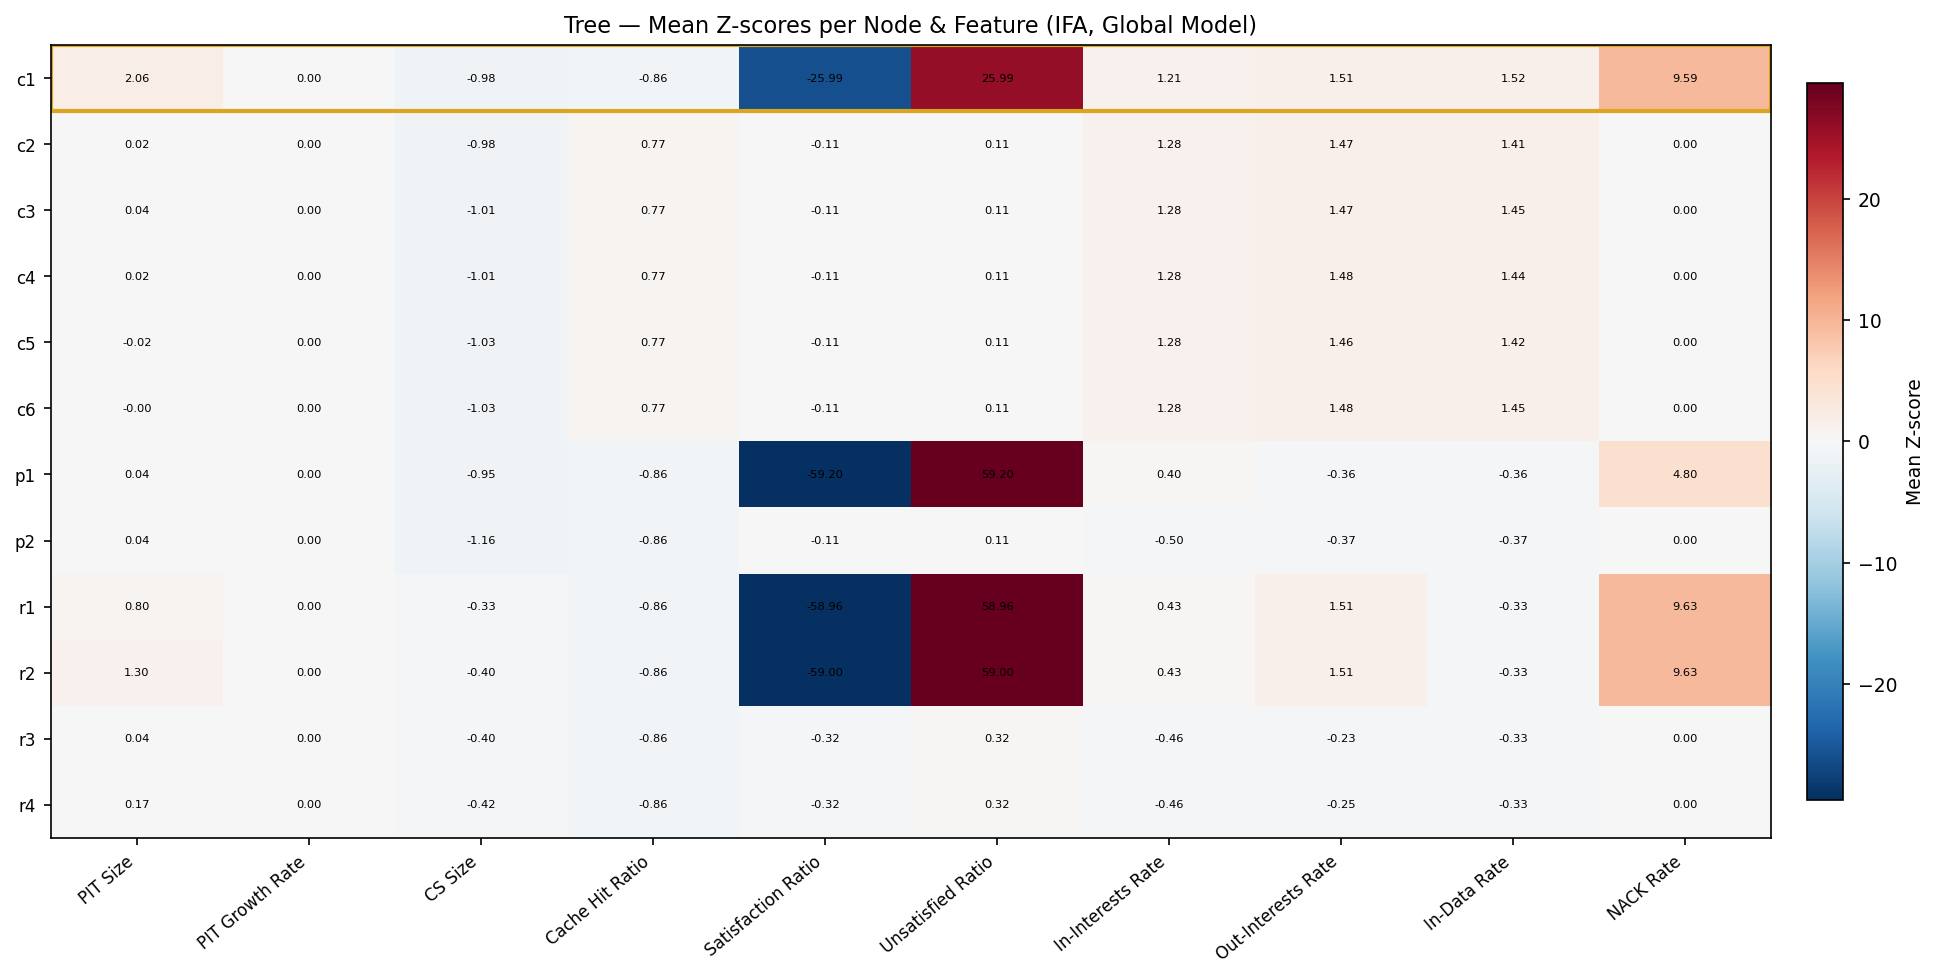

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_zscore_heatmap_tree.png


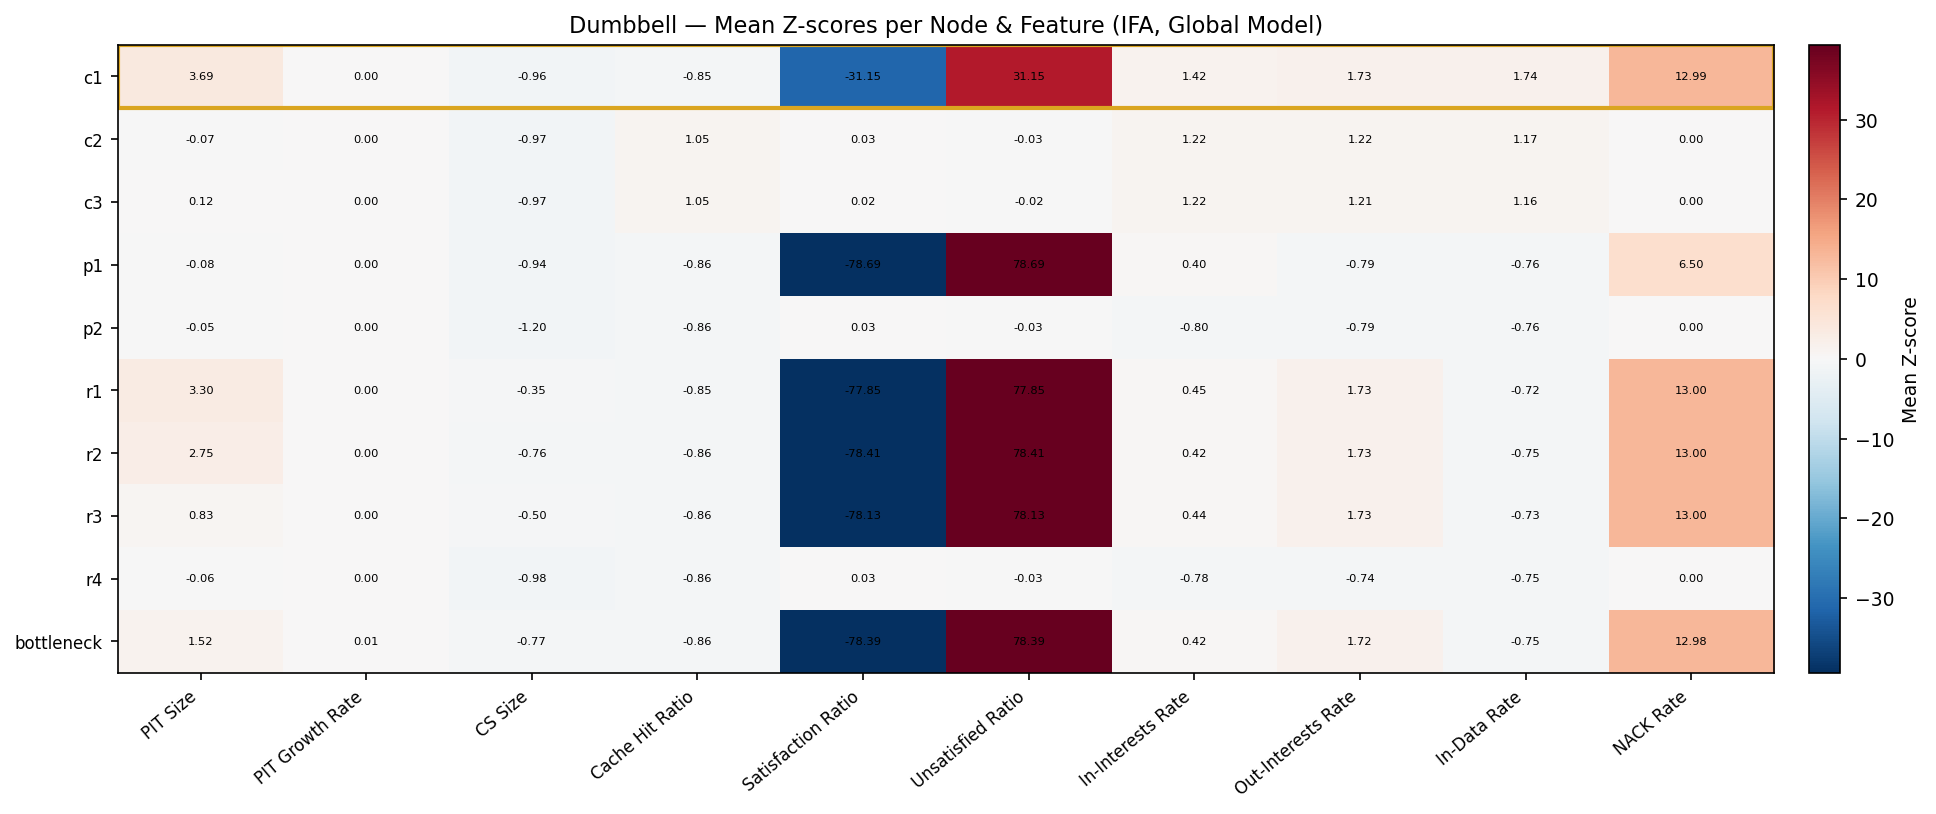

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_zscore_heatmap_dumbbell.png


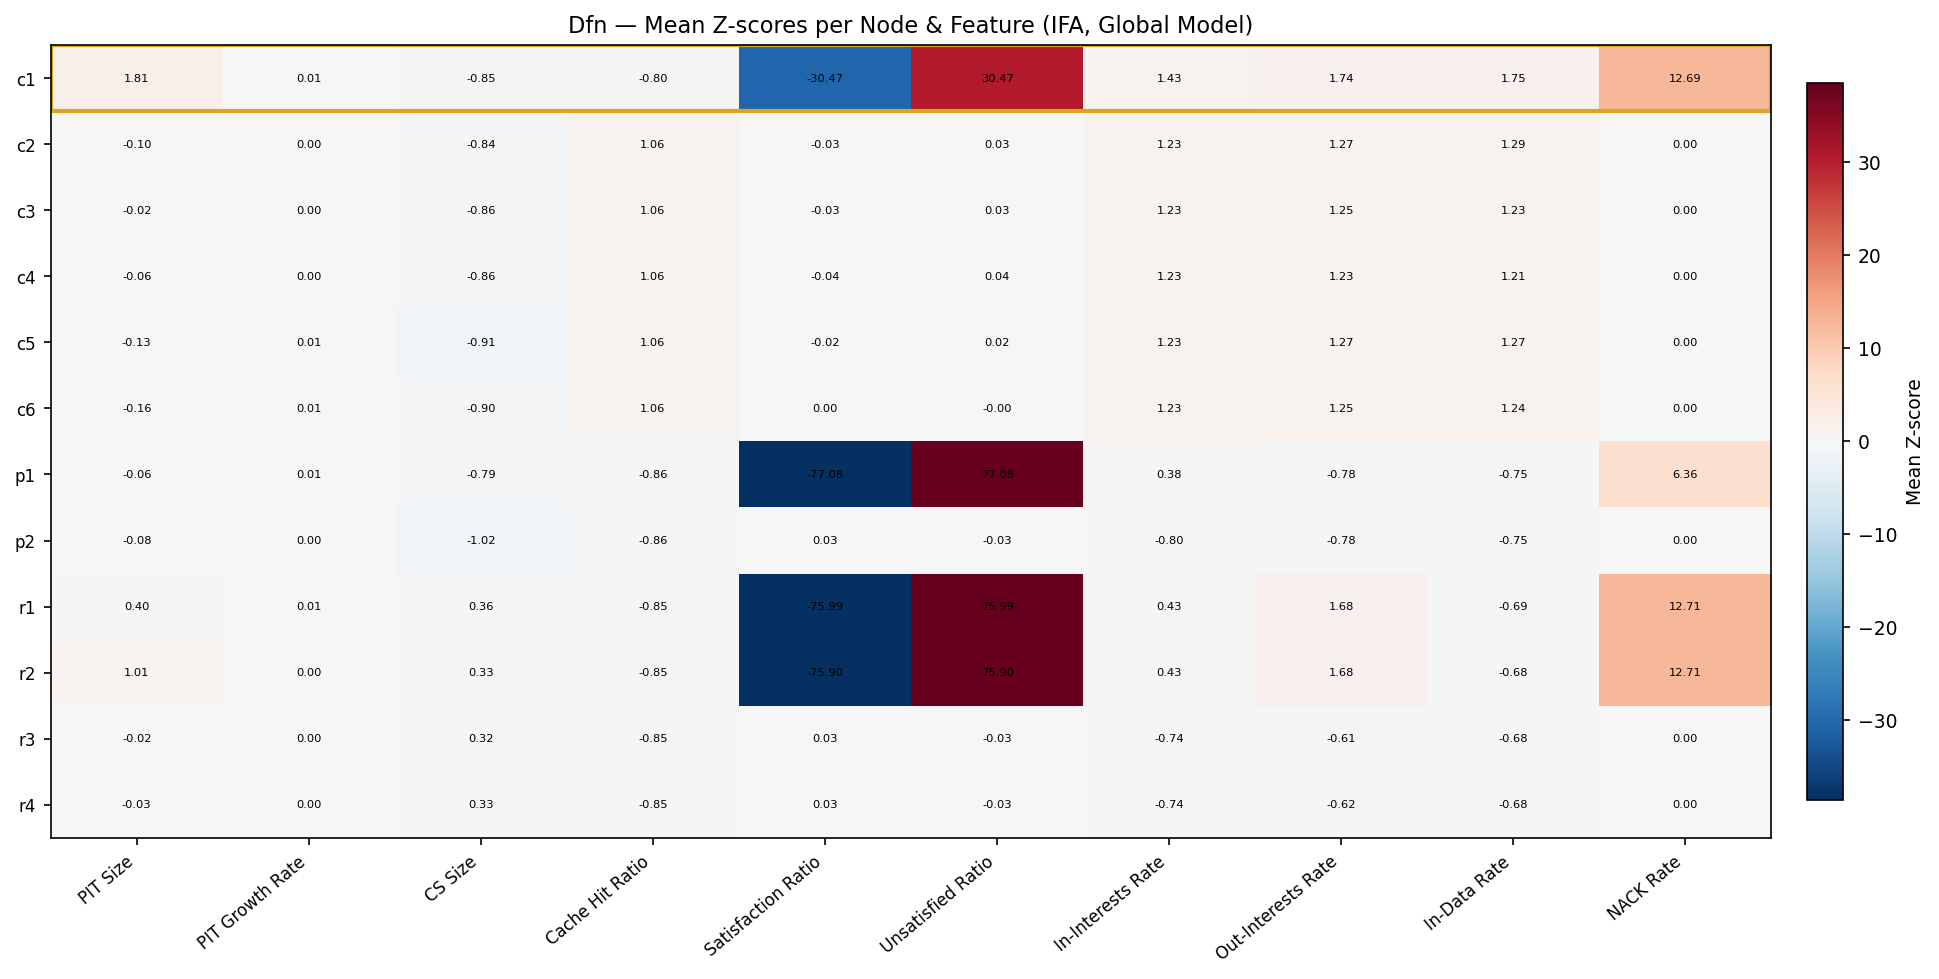

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_zscore_heatmap_dfn.png


In [8]:
def plot_zscore_heatmap(topo, df_ifa_topo, pipe):
    scaler = pipe.named_steps["scaler"]
    nodes  = sorted_nodes(df_ifa_topo["node"].unique().tolist())

    Z = []
    for nd in nodes:
        X_nd = df_ifa_topo[df_ifa_topo["node"] == nd][FEATURES].values
        z_nd = (X_nd - scaler.mean_) / scaler.scale_
        Z.append(z_nd.mean(axis=0))
    Z = np.array(Z)   # shape (n_nodes, n_features)

    peak = np.abs(Z).max()
    vlim = max(3.0, peak * 0.5)

    fig, ax = plt.subplots(figsize=(13, max(4, len(nodes) * 0.55)))
    im = ax.imshow(Z, aspect="auto", cmap="RdBu_r", vmin=-vlim, vmax=vlim)

    ax.set_xticks(range(len(FEATURES)))
    ax.set_xticklabels(FEAT_LABELS, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(len(nodes)))
    ax.set_yticklabels(nodes, fontsize=8)
    ax.set_title(f"{topo.capitalize()} — Mean Z-scores per Node & Feature (IFA, Global Model)")

    plt.colorbar(im, ax=ax, label="Mean Z-score", fraction=0.02, pad=0.02)

    # Annotate cells
    for i in range(len(nodes)):
        for j in range(len(FEATURES)):
            ax.text(j, i, f"{Z[i, j]:.2f}", ha="center", va="center",
                    fontsize=5.5, color="black")

    # Gold/red rectangle border around c1
    if ATTACKER in nodes:
        idx = nodes.index(ATTACKER)
        rect = Rectangle(
            (-0.5, idx - 0.5), len(FEATURES), 1,
            linewidth=2, edgecolor="goldenrod", facecolor="none"
        )
        ax.add_patch(rect)

    fig.tight_layout()
    out = FIG_DIR / f"fig_zscore_heatmap_{topo}.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out}")


for topo in TOPOLOGIES:
    plot_zscore_heatmap(topo, df_ifa_all[df_ifa_all["topology"] == topo], pipe)

## 5. Anomaly Score Timelines

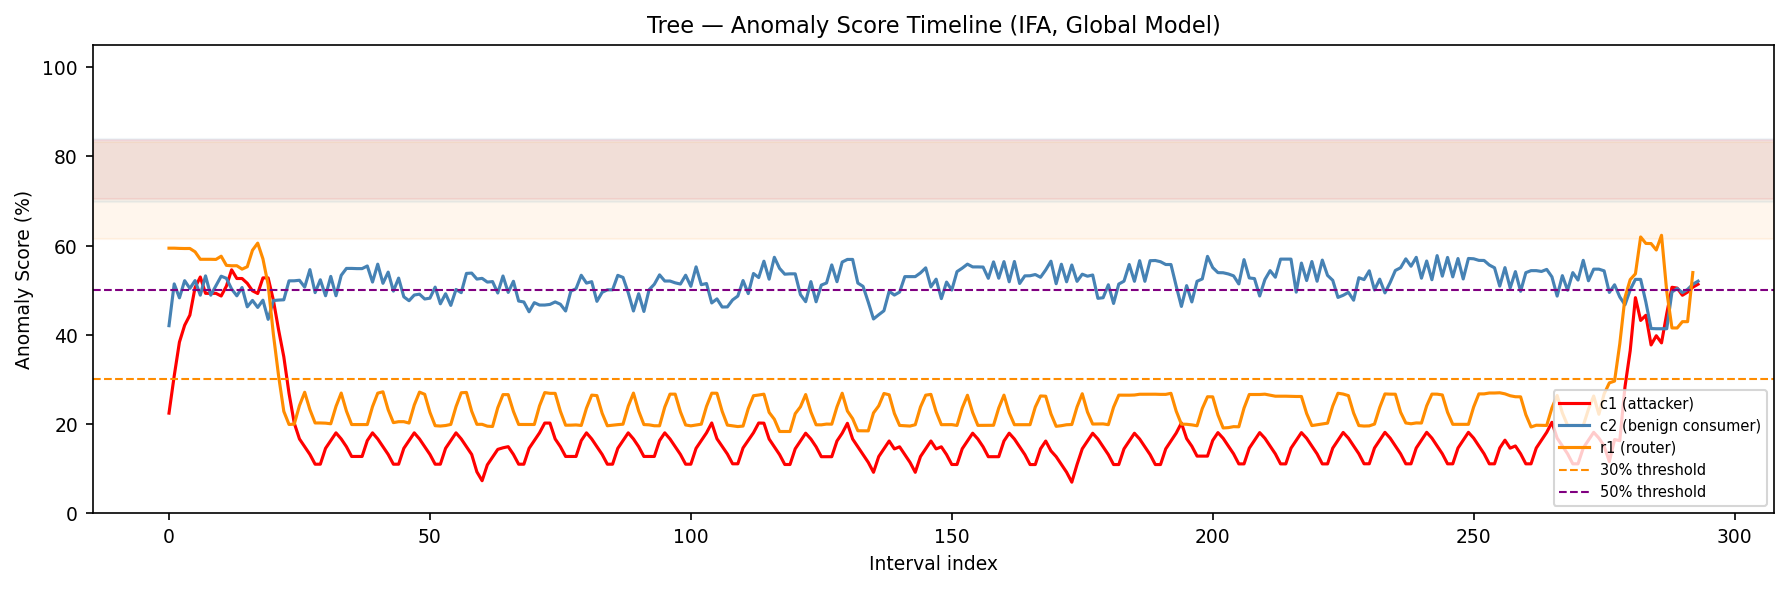

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_score_timeline_tree.png


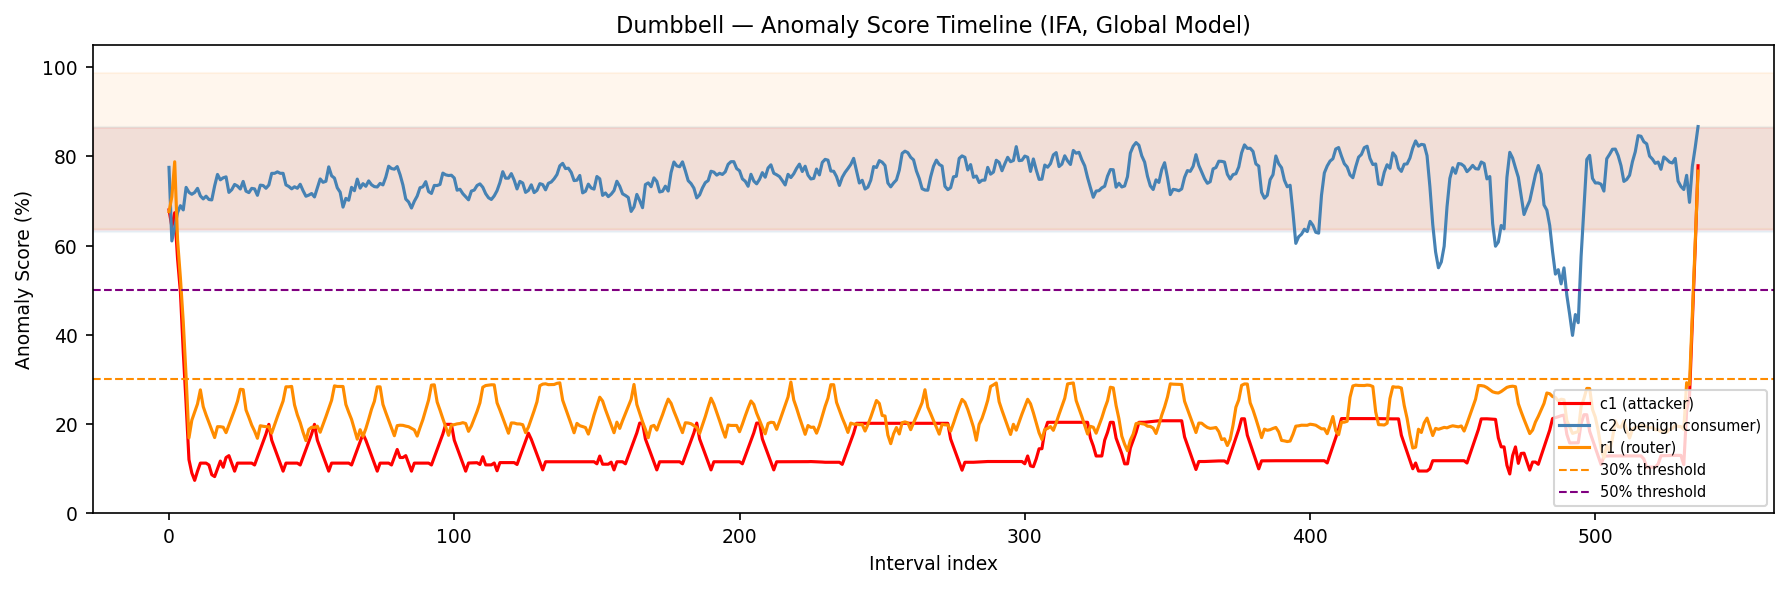

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_score_timeline_dumbbell.png


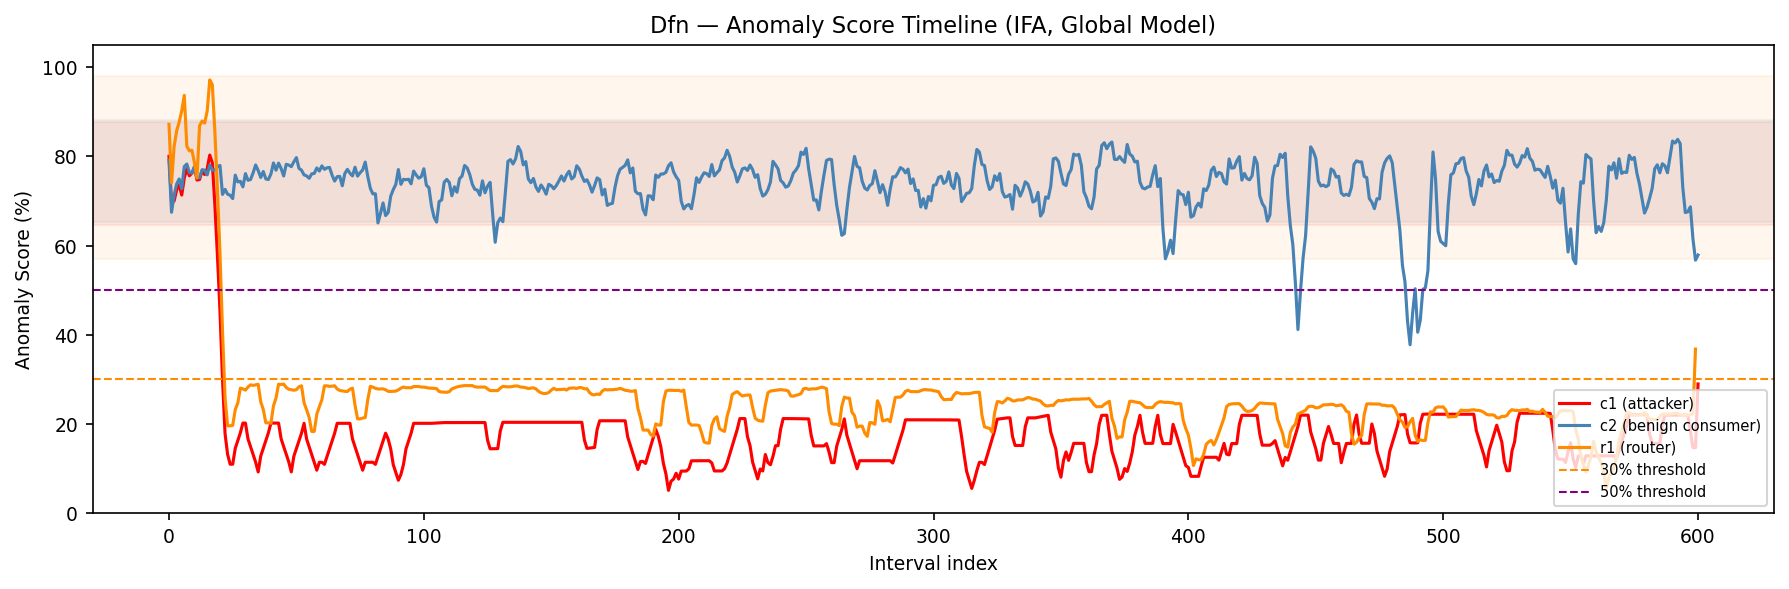

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_score_timeline_dfn.png


In [9]:
def plot_score_timeline(topo, df_ifa_topo):
    """
    Plot rolling-mean anomaly score timeline for c1, c2, r1.
    Also shows the normal baseline as a horizontal shaded band.
    """
    focus_nodes = [("c1", "red",    "c1 (attacker)"),
                   ("c2", "steelblue", "c2 (benign consumer)"),
                   ("r1", "darkorange",  "r1 (router)")]

    # Normal baseline per node (train set, same topology)
    mask_norm = df_normal_clipped["topology"] == topo
    df_norm_t = df_normal_clipped[mask_norm].copy()
    X_norm_t  = df_norm_t[FEATURES].values
    df_norm_t["norm_score"] = normalizer(pipe.decision_function(X_norm_t))

    fig, ax = plt.subplots(figsize=(12, 4))

    for nd, color, label in focus_nodes:
        df_nd = df_ifa_topo[df_ifa_topo["node"] == nd].copy()
        if df_nd.empty:
            continue

        roll = df_nd["norm_score"].rolling(5, min_periods=1).mean().values
        x    = np.arange(len(roll))
        ax.plot(x, roll, color=color, linewidth=1.5, label=label)

        # Normal baseline band
        norm_nd = df_norm_t[df_norm_t["node"] == nd]["norm_score"]
        if not norm_nd.empty:
            mu, sig = norm_nd.mean(), norm_nd.std()
            ax.axhspan(mu - sig, mu + sig, alpha=0.07, color=color)

    ax.axhline(30, color="darkorange", linestyle="--", linewidth=1, label="30% threshold")
    ax.axhline(50, color="purple",     linestyle="--", linewidth=1, label="50% threshold")

    ax.set_xlabel("Interval index")
    ax.set_ylabel("Anomaly Score (%)")
    ax.set_title(f"{topo.capitalize()} — Anomaly Score Timeline (IFA, Global Model)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=7, loc="lower right")

    fig.tight_layout()
    out = FIG_DIR / f"fig_score_timeline_{topo}.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out}")


for topo in TOPOLOGIES:
    plot_score_timeline(topo, df_ifa_all[df_ifa_all["topology"] == topo])

## 6. Threshold Sensitivity Analysis

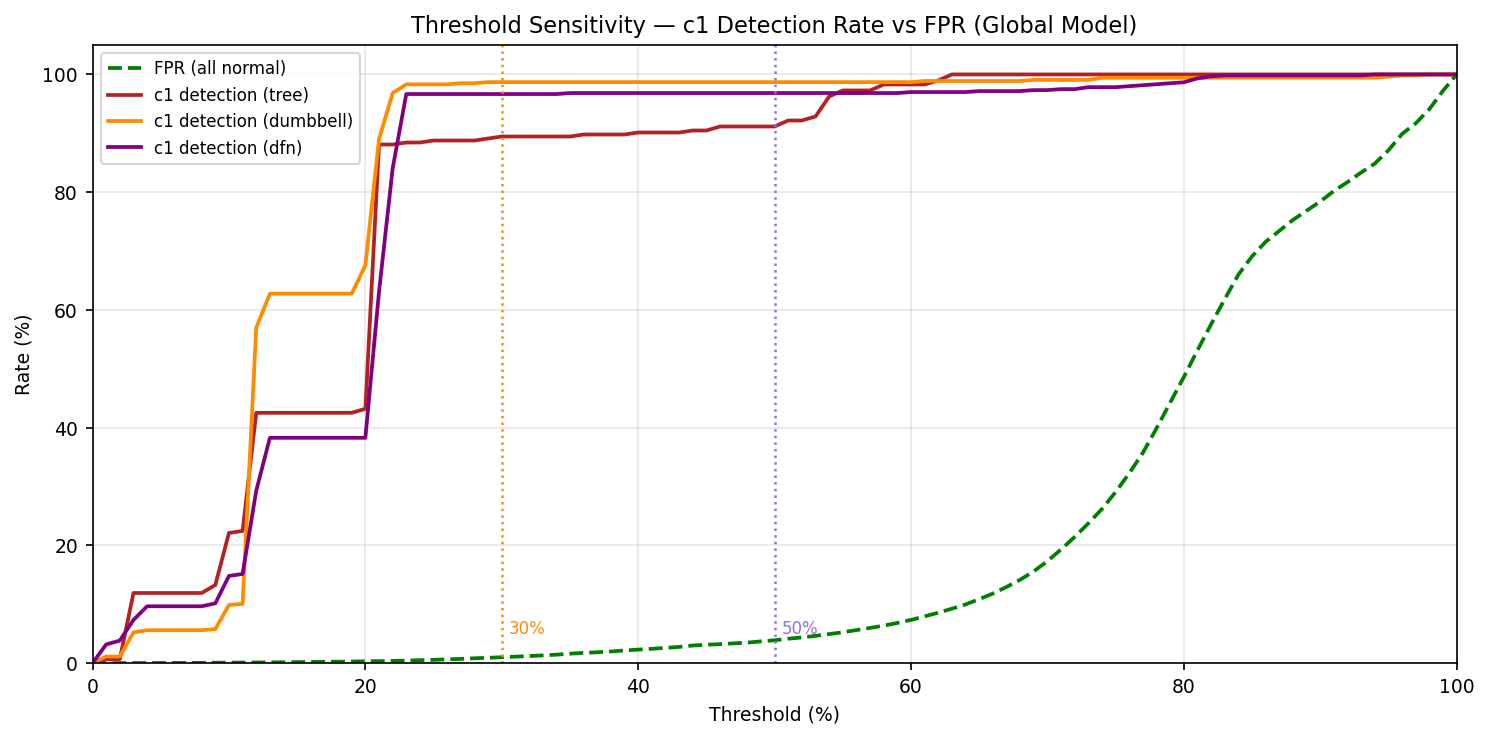

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_threshold_sensitivity.png


In [10]:
# ── Threshold sensitivity ─────────────────────────────────────────────────────
thresholds = np.arange(0, 101, 1)

# Normal scores (all topologies combined, from training set)
all_norm_scores = normalizer(pipe.decision_function(df_normal_clipped[FEATURES].values))

# c1 IFA scores per topology
topo_colors = {"tree": "firebrick", "dumbbell": "darkorange", "dfn": "purple"}

fig, ax = plt.subplots(figsize=(10, 5))

# FPR curve (single, global)
fpr_curve = [(all_norm_scores < T).mean() * 100 for T in thresholds]
ax.plot(thresholds, fpr_curve, "g--", linewidth=1.8, label="FPR (all normal)")

# Detection curve for c1 per topology
for topo, color in topo_colors.items():
    c1_scores = df_ifa_all[
        (df_ifa_all["topology"] == topo) & (df_ifa_all["node"] == ATTACKER)
    ]["norm_score"].values
    if len(c1_scores) == 0:
        continue
    det_curve = [(c1_scores < T).mean() * 100 for T in thresholds]
    ax.plot(thresholds, det_curve, color=color, linewidth=1.8,
            label=f"c1 detection ({topo})")

# Annotate operating points
for op_t, style in [(30, "darkorange"), (50, "mediumpurple")]:
    ax.axvline(op_t, color=style, linestyle=":", linewidth=1.2)
    ax.text(op_t + 0.5, 5, f"{op_t}%", color=style, fontsize=8)

ax.set_xlabel("Threshold (%)")
ax.set_ylabel("Rate (%)")
ax.set_title("Threshold Sensitivity — c1 Detection Rate vs FPR (Global Model)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
out = FIG_DIR / "fig_threshold_sensitivity.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## 7. Permutation Feature Importance

Computing permutation importance on normal data ...


Computing permutation importance on c1 attack data ...


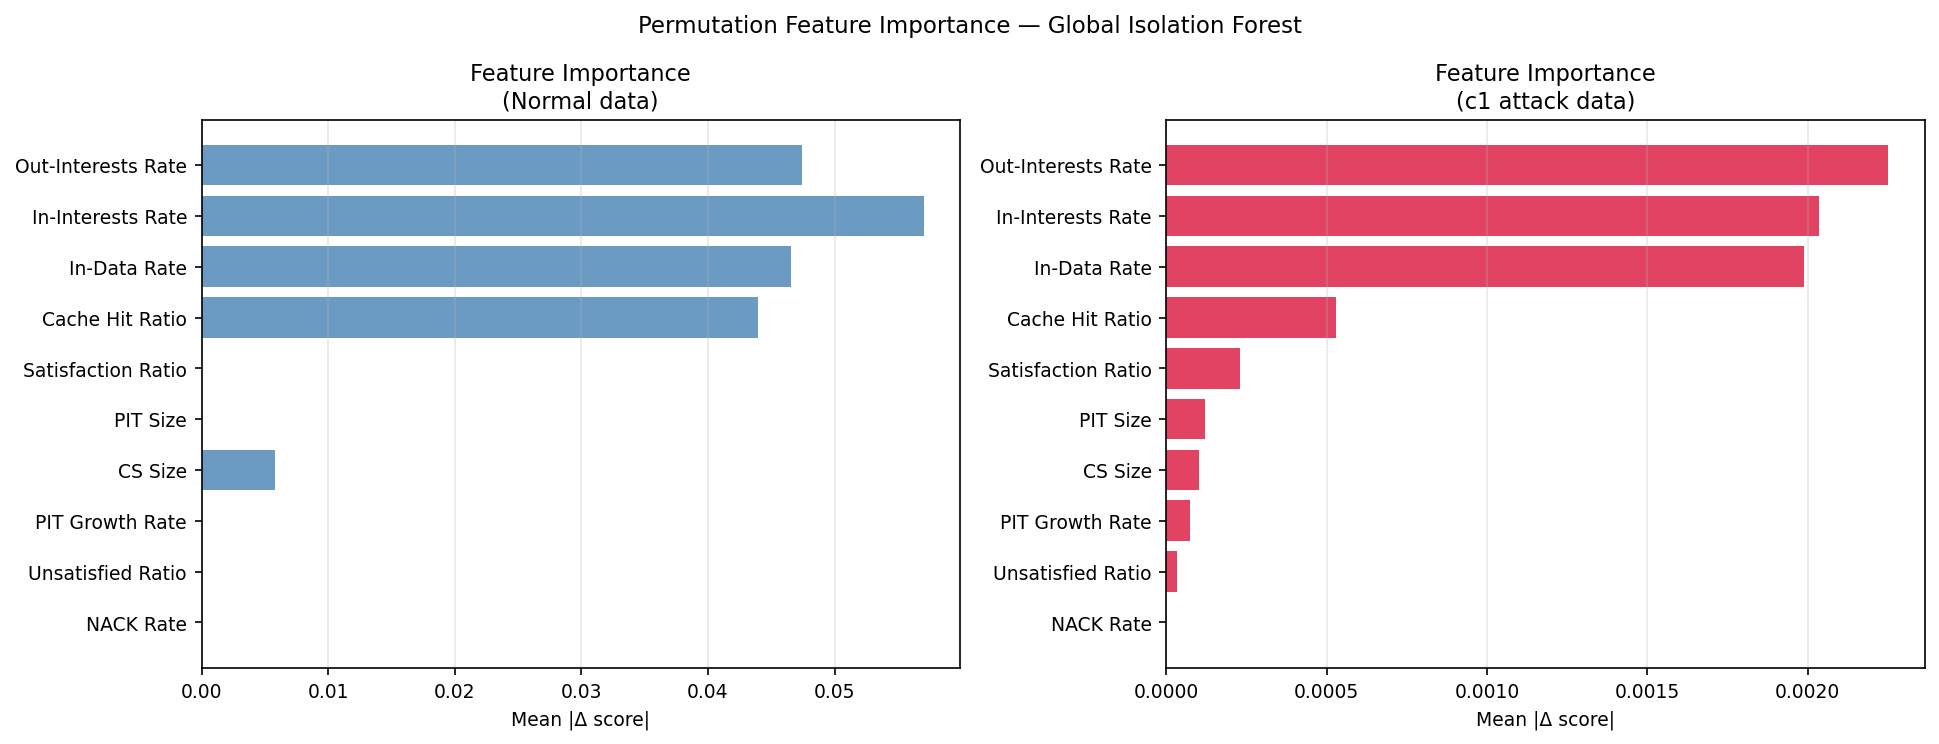

Saved → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/figures/global/fig_feature_importance.png


In [11]:
# ── Permutation feature importance ────────────────────────────────────────────
# We measure how much |mean decision_function score| drops when each feature is shuffled.

N_REPEATS = 10
rng = np.random.default_rng(42)

X_normal_eval = df_normal_clipped[FEATURES].values
X_c1_attack   = df_ifa_all[df_ifa_all["node"] == ATTACKER][FEATURES].values

def perm_importance(X_eval, n_repeats=N_REPEATS):
    """Mean absolute change in decision_function score when each feature is shuffled."""
    base_score = pipe.decision_function(X_eval).mean()
    importances = np.zeros((n_repeats, len(FEATURES)))
    for r in range(n_repeats):
        for j in range(len(FEATURES)):
            X_perm = X_eval.copy()
            rng.shuffle(X_perm[:, j])
            perm_score = pipe.decision_function(X_perm).mean()
            importances[r, j] = abs(base_score - perm_score)
    return importances.mean(axis=0)

print("Computing permutation importance on normal data ...")
imp_normal = perm_importance(X_normal_eval)
print("Computing permutation importance on c1 attack data ...")
imp_c1     = perm_importance(X_c1_attack)

# Sort by attack importance
order_c1     = np.argsort(imp_c1)
feat_ordered = [FEAT_LABELS[i] for i in order_c1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(feat_ordered, imp_normal[order_c1], color="steelblue", alpha=0.8)
axes[0].set_xlabel("Mean |Δ score|")
axes[0].set_title("Feature Importance\n(Normal data)")
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(feat_ordered, imp_c1[order_c1], color="crimson", alpha=0.8)
axes[1].set_xlabel("Mean |Δ score|")
axes[1].set_title("Feature Importance\n(c1 attack data)")
axes[1].grid(axis="x", alpha=0.3)

fig.suptitle("Permutation Feature Importance — Global Isolation Forest", fontsize=11)
fig.tight_layout()
out = FIG_DIR / "fig_feature_importance.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## 8. Per-Node Detection Table

In [12]:
# ── Per-node detection summary table ─────────────────────────────────────────
rows_ifa = []
for topo in TOPOLOGIES:
    df_t = df_ifa_all[df_ifa_all["topology"] == topo]
    for nd in sorted_nodes(df_t["node"].unique().tolist()):
        df_nd = df_t[df_t["node"] == nd]
        rows_ifa.append({
            "topology":      topo,
            "node":          nd,
            "node_type":     node_type(nd),
            "attacker":      nd == ATTACKER,
            "n_intervals":   len(df_nd),
            "mean_score":    round(df_nd["norm_score"].mean(), 2),
            "std_score":     round(df_nd["norm_score"].std(), 2),
            "det_30pct":     round(df_nd["anom_30"].mean() * 100, 2),
            "det_50pct":     round(df_nd["anom_50"].mean() * 100, 2),
        })

df_ifa_table = pd.DataFrame(rows_ifa)

# ── Per-node FPR on normal data ───────────────────────────────────────────────
rows_fpr = []
for topo in TOPOLOGIES:
    mask = df_normal_clipped["topology"] == topo
    df_t = df_normal_clipped[mask].copy()
    df_t["norm_score"] = normalizer(pipe.decision_function(df_t[FEATURES].values))
    df_t["anom_30"] = df_t["norm_score"] < 30
    df_t["anom_50"] = df_t["norm_score"] < 50

    for nd in sorted_nodes(df_t["node"].unique().tolist()):
        df_nd = df_t[df_t["node"] == nd]
        rows_fpr.append({
            "topology":    topo,
            "node":        nd,
            "node_type":   node_type(nd),
            "n_intervals": len(df_nd),
            "mean_score":  round(df_nd["norm_score"].mean(), 2),
            "fpr_30pct":   round(df_nd["anom_30"].mean() * 100, 2),
            "fpr_50pct":   round(df_nd["anom_50"].mean() * 100, 2),
        })

df_fpr_table = pd.DataFrame(rows_fpr)

# ── Display ───────────────────────────────────────────────────────────────────
print("=" * 70)
print("IFA Detection Rates per Node (Global Model)")
print("=" * 70)
display(df_ifa_table.style
        .format({"mean_score": "{:.2f}", "std_score": "{:.2f}",
                 "det_30pct": "{:.1f}%", "det_50pct": "{:.1f}%"})
        .highlight_max(subset=["det_30pct", "det_50pct"], axis=0,
                       color="#ffe0e0")
       )

print("\n" + "=" * 70)
print("Normal FPR per Node (Global Model)")
print("=" * 70)
display(df_fpr_table.style
        .format({"mean_score": "{:.2f}",
                 "fpr_30pct": "{:.1f}%", "fpr_50pct": "{:.1f}%"})
       )

# ── Save combined CSV ─────────────────────────────────────────────────────────
# Merge IFA + FPR tables side by side
df_combined = df_ifa_table.merge(
    df_fpr_table[["topology", "node", "fpr_30pct", "fpr_50pct"]],
    on=["topology", "node"], how="left"
)
out_csv = RES_DIR / "global_detection_per_node.csv"
df_combined.to_csv(out_csv, index=False)
print(f"\nSaved combined table → {out_csv}")
print(df_combined.to_string(index=False))

IFA Detection Rates per Node (Global Model)


,topology,node,node_type,attacker,n_intervals,mean_score,std_score,det_30pct,det_50pct
0,tree,c1,consumer,True,294,18.73,13.54,89.5%,91.2%
1,tree,c2,consumer,False,294,51.73,10.32,1.0%,51.4%
2,tree,c3,consumer,False,294,49.94,10.09,2.7%,54.8%
3,tree,c4,consumer,False,294,50.46,9.26,1.0%,56.1%
4,tree,c5,consumer,False,293,50.07,10.45,3.4%,54.6%
5,tree,c6,consumer,False,293,49.68,9.72,1.7%,58.0%
6,tree,p1,producer,False,294,39.02,6.01,1.0%,90.5%
7,tree,p2,producer,False,293,51.32,5.73,0.7%,34.1%
8,tree,r1,router,False,293,26.68,13.58,88.4%,90.1%
9,tree,r2,router,False,293,25.70,13.84,88.4%,90.1%



Normal FPR per Node (Global Model)


,topology,node,node_type,n_intervals,mean_score,fpr_30pct,fpr_50pct
0,tree,c1,consumer,1579,76.98,0.2%,1.1%
1,tree,c2,consumer,1579,76.94,0.2%,1.2%
2,tree,c3,consumer,1579,76.83,0.3%,1.3%
3,tree,c4,consumer,1579,76.66,0.4%,1.1%
4,tree,c5,consumer,1579,76.16,0.5%,2.3%
5,tree,c6,consumer,1579,76.59,0.3%,1.4%
6,tree,p1,producer,1579,74.79,0.3%,1.1%
7,tree,p2,producer,1579,75.15,0.4%,0.8%
8,tree,r1,router,1579,72.39,1.1%,3.2%
9,tree,r2,router,1578,73.52,0.9%,2.6%



Saved combined table → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/results/global_detection_per_node.csv
topology       node  node_type  attacker  n_intervals  mean_score  std_score  det_30pct  det_50pct  fpr_30pct  fpr_50pct
    tree         c1   consumer      True          294       18.73      13.54      89.46      91.16       0.19       1.08
    tree         c2   consumer     False          294       51.73      10.32       1.02      51.36       0.25       1.20
    tree         c3   consumer     False          294       49.94      10.09       2.72      54.76       0.32       1.27
    tree         c4   consumer     False          294       50.46       9.26       1.02      56.12       0.38       1.14
    tree         c5   consumer     False          293       50.07      10.45       3.41      54.61       0.51       2.34
    tree         c6   consumer     False          293       49.68       9.72       1.71      58.02       0.32       1.39
    tree    

In [13]:
# ── Persist the trained global model (reproducibility) ────────────────────
import joblib, json

MODEL_DIR = PROJECT_ROOT / "research_analysis" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipe, MODEL_DIR / "global_ifa_model.joblib")
meta = {
    "features":           FEATURES,
    "clip_bounds":        {k: {"lo": float(v[0]), "hi": float(v[1])} for k, v in clip_bounds.items()},
    "threshold":          THRESHOLD,
    "score_min":          SCORE_MIN,
    "score_max":          SCORE_MAX,
    "n_training_samples": int(len(X_train)),
    "trained_on":         [d.name for info in TOPOLOGIES.values() for d in info["normal_dirs"]],
}
(MODEL_DIR / "global_ifa_model_meta.json").write_text(json.dumps(meta, indent=2, default=float))
print(f"Saved global model + metadata \u2192 {MODEL_DIR}")


Saved global model + metadata → /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/models
